In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

## Pre-processing
Load data, clean up encoding issues and rectify missing party association

In [3]:
speech_data = pd.read_json('speech_emotions_2015_2025.json')

party_replacement_dict = {
    'BÃ¼ndnis 90/Die GrÃ¼nen' : 'BÜNDNIS 90/DIE GRÜNEN', 
    'CDU': 'CDU/CSU',
    'fraktionslos': 'Fraktionslos',
    'Die Linke': 'DIE LINKE',
    'CSU': 'CDU/CSU'
}

# Replace weird formatting issues in party names
speech_data['party'] = speech_data['party'].replace(party_replacement_dict) 

# Some speakers have no party affiliation, this is the case for people who hold offices within the government, but are not ministers.
# We will rectify party association for speakers with at least 10 speeches.
mask = speech_data['party'] == ''
no_party = speech_data[mask]
speaker_names = no_party['speaker_first_name'] + " " + no_party['speaker_last_name']
speaker_counts = speaker_names.value_counts()
speaker_counts[speaker_counts >= 10]

party_fixes = {
    'Cem Özdemir': 'BÜNDNIS 90/DIE GRÜNEN', 'Gerd Müller': 'CDU/CSU', 'Julia Klöckner': 'CDU/CSU',
    'Thomas de Maizière': 'CDU/CSU', 'Christian Lange': 'SPD', 'Michael Roth': 'SPD', 
    'Günter Krings': 'CDU/CSU', 'Wolfang Schäuble': 'CDU/CSU', 'Johann David Wadephul': 'CDU/CSU',
    'Rita Schwarzelühr-Sutter': 'SPD', 'Dorothee Bär': 'CDU/CSU', 'Ole Schröder': 'CDU/CSU',
    'Hermann Gröhe': 'CDU/CSU', 'Michael Meister': 'CDU/CSU', 'Michael Kellner': 'BÜNDNIS 90/DIE GRÜNEN',
    'Florian Pronold': 'SPD', 'Enak Ferlemann': 'CDU/CSU', 'Kerstin Griese': 'SPD',
    'Ursula Leyen': 'CDU/CSU', 'Niels Annen': 'SPD', 'Thomas Silberhorn': 'CDU/CSU',
    'Steffen Bilger': 'CDU/CSU', 'Ralf Brauksiepe': 'CDU/CSU', 'Stephan Mayer': 'CDU/CSU',
    'Thomas Maizière': 'CDU/CSU', 'Monika Grütters': 'CDU/CSU', 'Sarah Ryglewski': 'SPD',
    'Uwe Beckmeyer': 'SPD', 'Anette Kramme': 'SPD', 'Maria Flachsbarth': 'CDU/CSU',
    'Franziska Brantner': 'BÜNDNIS 90/DIE GRÜNEN', 'Maria Böhmer': 'CDU/CSU', 
    'Anette Widmann-Mauz': 'CDU/CSU', 'Peter Tauber': 'CDU/CSU', 'Thomas Gebhart': 'CDU/CSU',
    'Anna Lührmann': 'BÜNDNIS 90/DIE GRÜNEN', 'Benjamin Strasser': 'FDP', 
    'Hans-Joachim Fuchtel': 'CDU/CSU', 'Claudia Roth': 'BÜNDNIS 90/DIE GRÜNEN',
    'Gabriele Lösekrug-Möller': 'SPD', 'Marco Wanderwitz': 'CDU/CSU', 'Thomas Rachel': 'CDU/CSU',
    'Thomas Bareiß': 'CDU/CSU', 'Iris Gleicke': 'SPD', 'Ulrich Kelber': 'SPD',
    'Rita Hagl-Kehl': 'SPD', 'Bettina Hagedorn': 'SPD'
}

for name, party in party_fixes.items():
    speech_data.loc[(speech_data['speaker_first_name'] + " " + speech_data['speaker_last_name'] == name) & (speech_data['party'] == ''), 'party'] = party

# Remove entries with weird party affiliations, such as local politicians from Bremen or Fraktionslos, or BSW

parties_to_keep = ['CDU/CSU', 'SPD', 'FDP', 'DIE LINKE', 'BÜNDNIS 90/DIE GRÜNEN', "AfD"]
speech_data = speech_data[speech_data['party'].isin(parties_to_keep)]

In [4]:
  # Define party colors
party_colors = {
    'AfD': '#009ee0',  # Light blue
    'CDU/CSU': '#000000',  # Black
    'BÜNDNIS 90/DIE GRÜNEN': '#46962b',  # Green
    'SPD': '#e3000f',  # Red
    'FDP': '#ffed00',  # Yellow
    'DIE LINKE': '#e6007e'  # Pink/Magenta
}

# Event annotations (number markers)
events = {
    '2015-09-30': '5',
    '2015-12-31': '6',
    '2016-12-19': '7',
    '2020-03-22': '8',
    '2021-12-08': '9',
    '2022-02-24': '10',
    '2023-04-07': '11',
    '2024-11-06': '12',
    '2024-12-11': '13'
}

# Federal elections
elections = {
    '2017-09-24': '2017 Election',
    '2021-09-26': '2021 Election',
    '2025-02-23': '2025 Election'
}

# Event descriptions for legend
event_descriptions = {
    '5': 'Refugee Crisis Peak (Sep 2015)',
    '6': 'Cologne New Year\'s Assaults (Dec 2015)',
    '7': 'Berlin Christmas Market Attack (Dec 2016)',
    '8': 'First COVID Lockdown (Mar 2020)',
    '9': 'Scholz elected Chancellor (Dec 2021)',
    '10': 'Ukraine War (Feb 2022)',
    '11': 'End of COVID Restrictions (Apr 2023)',
    '12': 'Ampel Collapse (Nov 2024)'
}

# Party-specific annotations
party_annotations = {
    'AfD': [
        {'date': '2022-06-18', 'label': '1', 'description': 'Weidel co-leader of AfD (Jun 2022)'}
    ],
    'DIE LINKE': [
        {'date': '2023-10-23', 'label': '2', 'description': 'Wagenknecht leaves Die Linke (Oct 2023)'}
    ],
    'CDU/CSU': [
        {'date': '2021-03-07', 'label': '3', 'description': 'Maskenaffäre (Mar 2021)'},
        {'date': '2024-12-11', 'label': '4', 'description': 'Merz elected CDU leader (Dec 2024)'}
    ]
}

In [28]:
def plot_emotion_over_time(emotion_name, window_size=12):
    # Convert date to datetime
    speech_data_copy = speech_data.copy()
    speech_data_copy['date'] = pd.to_datetime(speech_data_copy['date'])
    
    # Extract emotions and turn them into a dataframe
    emotion_rows = []
    for _, row in speech_data_copy.iterrows():
        for emotion, score in row['emotions'].items():
            if emotion == emotion_name:
                emotion_rows.append({
                    'date': row['date'],
                    'party': row['party'],
                    'emotion': emotion,
                    'score': score
                })
    
    emotion_df = pd.DataFrame(emotion_rows)
    
    # Filter for the specific emotion
    emotion_df = emotion_df[emotion_df['emotion'] == emotion_name]
    
    # Filter out parties that were not in parliament during certain periods
    # FDP and AfD were not in Bundestag during 18th legislature (before 2017-10-24)
    fdp_afd_entry_date = pd.to_datetime('2017-10-24')
    mask = ~((emotion_df['party'].isin(['FDP', 'AfD'])) & (emotion_df['date'] < fdp_afd_entry_date))
    emotion_df = emotion_df[mask]
    
    # Group by month, party, and emotion to get average scores
    emotion_df['year_month'] = emotion_df['date'].dt.to_period('M')
    monthly_emotions = emotion_df.groupby(['year_month', 'party'])['score'].mean().reset_index()
    monthly_emotions['year_month'] = monthly_emotions['year_month'].dt.to_timestamp()
    
    # Apply rolling average for smoothing per party, we use gaussian to smooth the curves for easier intrerpretability
    smoothed_data = []
    for party in monthly_emotions['party'].unique():
        party_subset = monthly_emotions[monthly_emotions['party'] == party].copy()
        party_subset = party_subset.sort_values('year_month')
        party_subset['score_smoothed'] = party_subset['score'].rolling(
            window=window_size, center=False, min_periods=1, win_type='gaussian').mean(std=3)
        smoothed_data.append(party_subset)
    
    monthly_emotions_smoothed = pd.concat(smoothed_data)
    
    # Calculate overall average (average across all parties) and smooth it
    overall_monthly = monthly_emotions.groupby('year_month')['score'].mean().reset_index()
    overall_monthly = overall_monthly.sort_values('year_month')
    overall_monthly['score_smoothed'] = overall_monthly['score'].rolling(
        window=window_size, center=False, min_periods=1, win_type='gaussian').mean(std=3)
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))
    for party in parties_to_keep:
        party_data = monthly_emotions_smoothed[monthly_emotions_smoothed['party'] == party]
        if len(party_data) > 0:
            ax.plot(party_data['year_month'], party_data['score_smoothed'], 
                    label=party, linewidth=2, color=party_colors.get(party, 'gray'))
            
            # Add party-specific annotations
            if party in party_annotations:
                for annotation in party_annotations[party]:
                    ann_date = pd.to_datetime(annotation['date'])
                    # Find the score value at this date
                    closest_idx = (party_data['year_month'] - ann_date).abs().argmin()
                    ann_y = party_data.iloc[closest_idx]['score_smoothed']
                    
                    ax.annotate(annotation['label'], 
                               xy=(ann_date, ann_y),
                               xytext=(0, 10), textcoords='offset points',
                               fontsize=12, fontweight='bold',
                               color=party_colors.get(party, 'gray'),
                               ha='center',
                               bbox=dict(boxstyle='circle,pad=0.3', 
                                       facecolor='white', 
                                       edgecolor=party_colors.get(party, 'gray'),
                                       linewidth=2))
    
    # Add overall smoothed average line
    ax.plot(overall_monthly['year_month'], overall_monthly['score_smoothed'], 
             color='grey', linestyle='-', linewidth=3, alpha=0.8, 
             label='Overall Average (All Parties)')
    
    # Add event markers with numbers
    for date_str, event_number in events.items():
        event_date = pd.to_datetime(date_str)
        ax.axvline(x=event_date, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(event_date, ax.get_ylim()[1] * 0.98, event_number, 
                ha='center', fontsize=10, fontweight='bold', 
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='gray', linewidth=1))
    
    # Add election markers with thick black vertical bars
    for date_str, election_name in elections.items():
        election_date = pd.to_datetime(date_str)
        ax.axvline(x=election_date, color='black', linestyle='-', linewidth=3, alpha=0.8, zorder=5)
    # Labels and title
    ax.set_xlabel('Date')
    ax.set_ylabel(f'{emotion_name} "Proportion" ({window_size}-month rolling average)')
    ax.set_title(f'{emotion_name} over Time - All Parties', fontsize=18)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

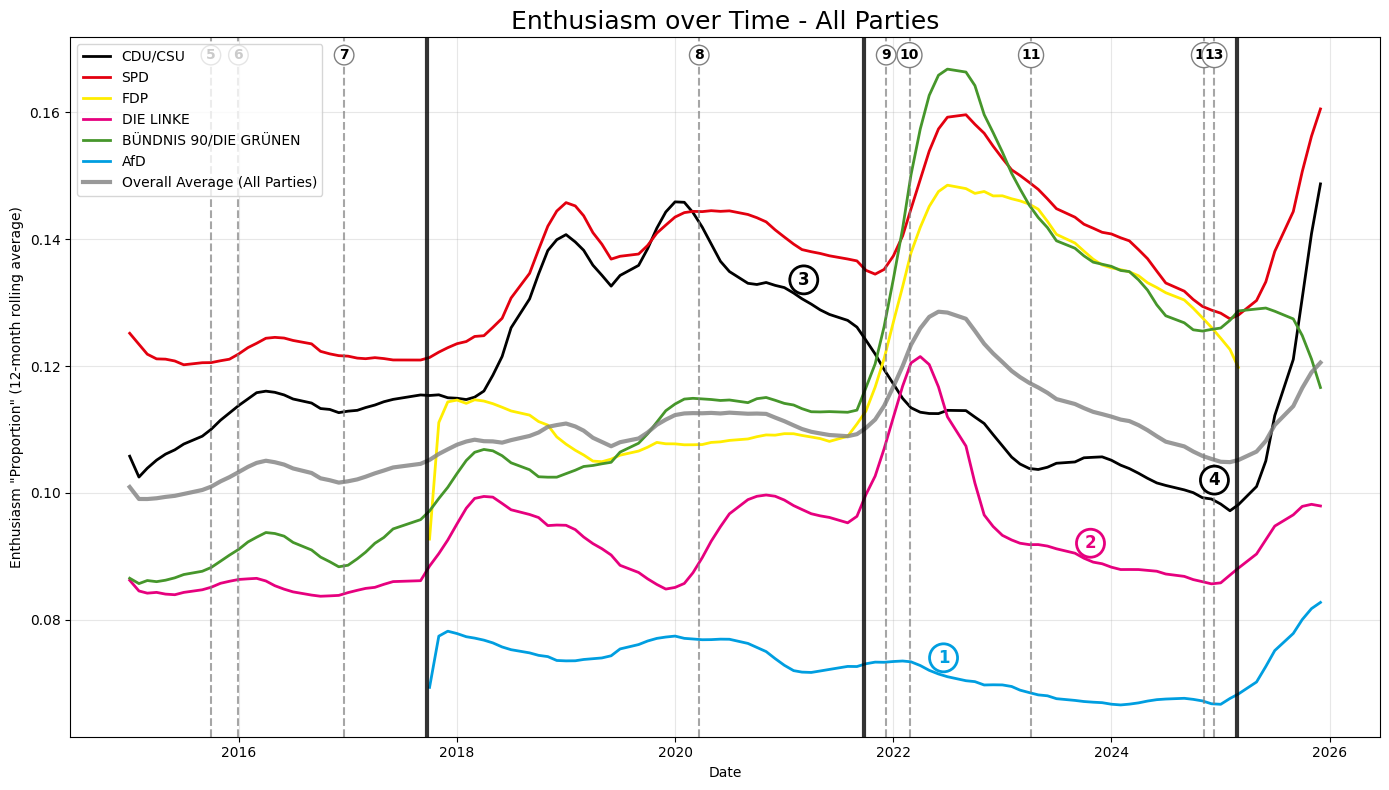

In [33]:
plot_emotion_over_time('Enthusiasm', window_size=12)

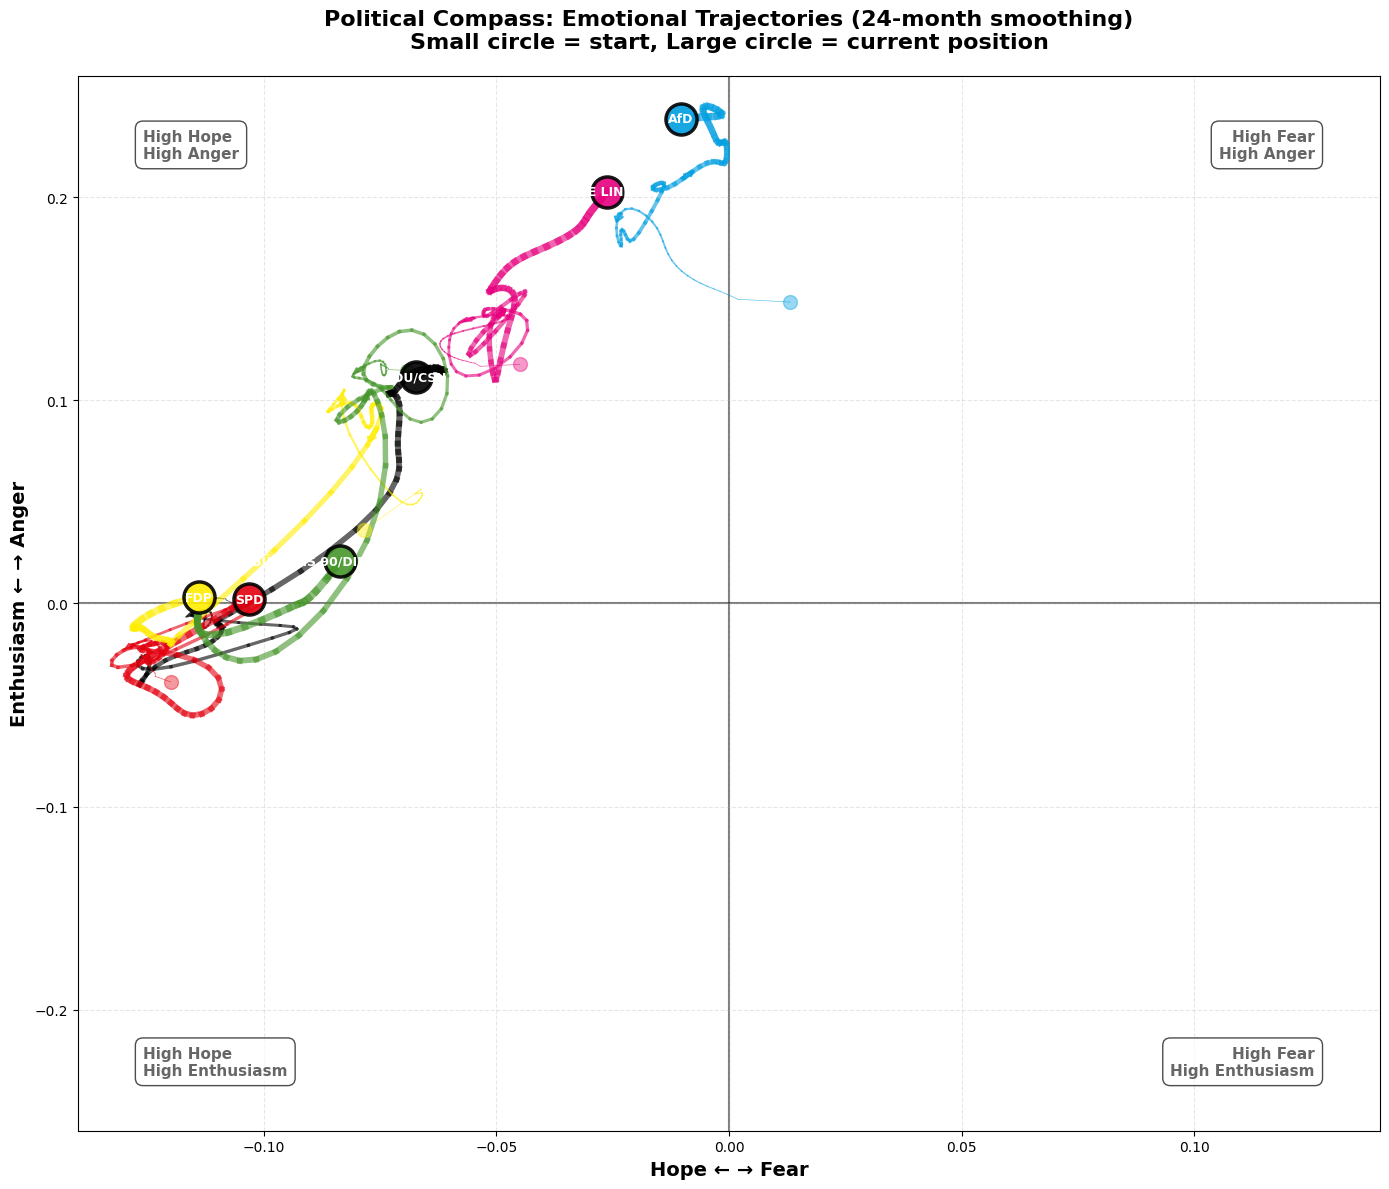

In [11]:
# Political Compass with Trajectories: Show how parties evolved emotionally over time
# X-axis: Hope (left) to Fear (right)
# Y-axis: Enthusiasm (bottom) to Anger (top)

def create_emotional_compass_with_trajectories(time_window_months=12):
    # Prepare data with dates
    speech_data_copy = speech_data.copy()
    speech_data_copy['date'] = pd.to_datetime(speech_data_copy['date'])
    speech_data_copy = speech_data_copy.sort_values('date')
    
    # Calculate trajectories for each party
    fig, ax = plt.subplots(figsize=(14, 12))
    
    trajectory_data = []
    
    for party in parties_to_keep:
        party_speeches = speech_data_copy[speech_data_copy['party'] == party].copy()
        
        if len(party_speeches) == 0:
            continue
        
        # Create monthly aggregates
        party_speeches['year_month'] = party_speeches['date'].dt.to_period('M')
        
        monthly_emotions = []
        for month in party_speeches['year_month'].unique():
            month_data = party_speeches[party_speeches['year_month'] == month]
            
            # Calculate average emotions for this month
            hope = month_data['emotions'].apply(lambda x: x.get('Hope', 0)).mean()
            fear = month_data['emotions'].apply(lambda x: x.get('Fear', 0)).mean()
            anger = month_data['emotions'].apply(lambda x: x.get('Anger', 0)).mean()
            enthusiasm = month_data['emotions'].apply(lambda x: x.get('Enthusiasm', 0)).mean()
            
            monthly_emotions.append({
                'month': month.to_timestamp(),
                'hope': hope,
                'fear': fear,
                'anger': anger,
                'enthusiasm': enthusiasm,
                'x': fear - hope,
                'y': anger - enthusiasm
            })
        
        if len(monthly_emotions) == 0:
            continue
            
        traj_df = pd.DataFrame(monthly_emotions).sort_values('month')
        
        # Apply Gaussian smoothing
        if len(traj_df) > time_window_months:
            traj_df['x_smooth'] = traj_df['x'].rolling(
                window=time_window_months, center=False, min_periods=1, win_type='gaussian').mean(std=3)
            traj_df['y_smooth'] = traj_df['y'].rolling(
                window=time_window_months, center=False, min_periods=1, win_type='gaussian').mean(std=3)
        else:
            traj_df['x_smooth'] = traj_df['x']
            traj_df['y_smooth'] = traj_df['y']
        
        color = party_colors.get(party, 'gray')
        
        # Plot trajectory line with varying thickness (thin at start, thick at end)
        for i in range(len(traj_df) - 1):
            # Calculate linewidth that increases from 0.5 to 3.5 along trajectory
            progress = i / (len(traj_df) - 1)
            linewidth = 0.5 + 5 * progress
            
            ax.plot(traj_df['x_smooth'].iloc[i:i+2], 
                   traj_df['y_smooth'].iloc[i:i+2],
                   color=color, linewidth=linewidth, alpha=0.6, zorder=2)
        
        # Add direction arrows along the trajectory
        n_arrows = 3  # Number of arrows to show
        if len(traj_df) >= 2:
            arrow_indices = np.linspace(len(traj_df)//4, len(traj_df)-2, n_arrows, dtype=int)
            for idx in arrow_indices:
                if idx + 1 < len(traj_df):
                    dx = traj_df.iloc[idx+1]['x_smooth'] - traj_df.iloc[idx]['x_smooth']
                    dy = traj_df.iloc[idx+1]['y_smooth'] - traj_df.iloc[idx]['y_smooth']
                    ax.arrow(traj_df.iloc[idx]['x_smooth'], 
                            traj_df.iloc[idx]['y_smooth'],
                            dx * 0.5, dy * 0.5,
                            head_width=0.002, head_length=0.003, 
                            fc=color, ec=color, alpha=0.7, zorder=2)
        
        # Plot start position (small circle)
        ax.scatter(traj_df.iloc[0]['x_smooth'], traj_df.iloc[0]['y_smooth'], 
                  s=100, color=color, alpha=0.4, edgecolors=color, 
                  linewidths=1, zorder=3, marker='o')
        
        # Plot end position (large circle with party label)
        final_x = traj_df.iloc[-1]['x_smooth']
        final_y = traj_df.iloc[-1]['y_smooth']
        
        ax.scatter(final_x, final_y, s=500, color=color, alpha=0.9, 
                  edgecolors='black', linewidths=2.5, zorder=4)
        
        # Add party label at final position
        ax.text(final_x, final_y, party, ha='center', va='center', 
               fontsize=9, fontweight='bold', color='white', zorder=5)
        
        trajectory_data.append({
            'party': party,
            'start_date': traj_df.iloc[0]['month'],
            'end_date': traj_df.iloc[-1]['month'],
            'start_x': traj_df.iloc[0]['x_smooth'],
            'start_y': traj_df.iloc[0]['y_smooth'],
            'end_x': final_x,
            'end_y': final_y,
            'total_distance': np.sqrt((final_x - traj_df.iloc[0]['x_smooth'])**2 + 
                                     (final_y - traj_df.iloc[0]['y_smooth'])**2)
        })
    
    # Add quadrant lines
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)
    
    # Make axis limits symmetric
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    max_x = max(abs(xlim[0]), abs(xlim[1]))
    max_y = max(abs(ylim[0]), abs(ylim[1]))
    ax.set_xlim(-max_x, max_x)
    ax.set_ylim(-max_y, max_y)
    
    # Update limits after setting symmetric axes
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    label_offset_x = (xlim[1] - xlim[0]) * 0.05
    label_offset_y = (ylim[1] - ylim[0]) * 0.05
    
    # Axis labels at the extremes
    ax.text(xlim[0] + label_offset_x, ylim[1] - label_offset_y, 
           'High Hope\nHigh Anger', ha='left', va='top', 
           fontsize=11, fontweight='bold', alpha=0.6, 
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))
    
    ax.text(xlim[0] + label_offset_x, ylim[0] + label_offset_y, 
           'High Hope\nHigh Enthusiasm', ha='left', va='bottom', 
           fontsize=11, fontweight='bold', alpha=0.6,
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))
    
    ax.text(xlim[1] - label_offset_x, ylim[1] - label_offset_y, 
           'High Fear\nHigh Anger', ha='right', va='top', 
           fontsize=11, fontweight='bold', alpha=0.6, 
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))
    
    ax.text(xlim[1] - label_offset_x, ylim[0] + label_offset_y, 
           'High Fear\nHigh Enthusiasm', ha='right', va='bottom', 
           fontsize=11, fontweight='bold', alpha=0.6,
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))
    
    # Labels and title
    ax.set_xlabel('Hope ← → Fear', fontsize=14, fontweight='bold')
    ax.set_ylabel('Enthusiasm ← → Anger', fontsize=14, fontweight='bold')
    ax.set_title(f'Political Compass: Emotional Trajectories ({time_window_months}-month smoothing)\nSmall circle = start, Large circle = current position', 
                fontsize=16, fontweight='bold', pad=20)
    
    ax.grid(True, alpha=0.3, linestyle='--', zorder=0)
    
    plt.tight_layout()
    plt.show()

create_emotional_compass_with_trajectories(time_window_months=24)

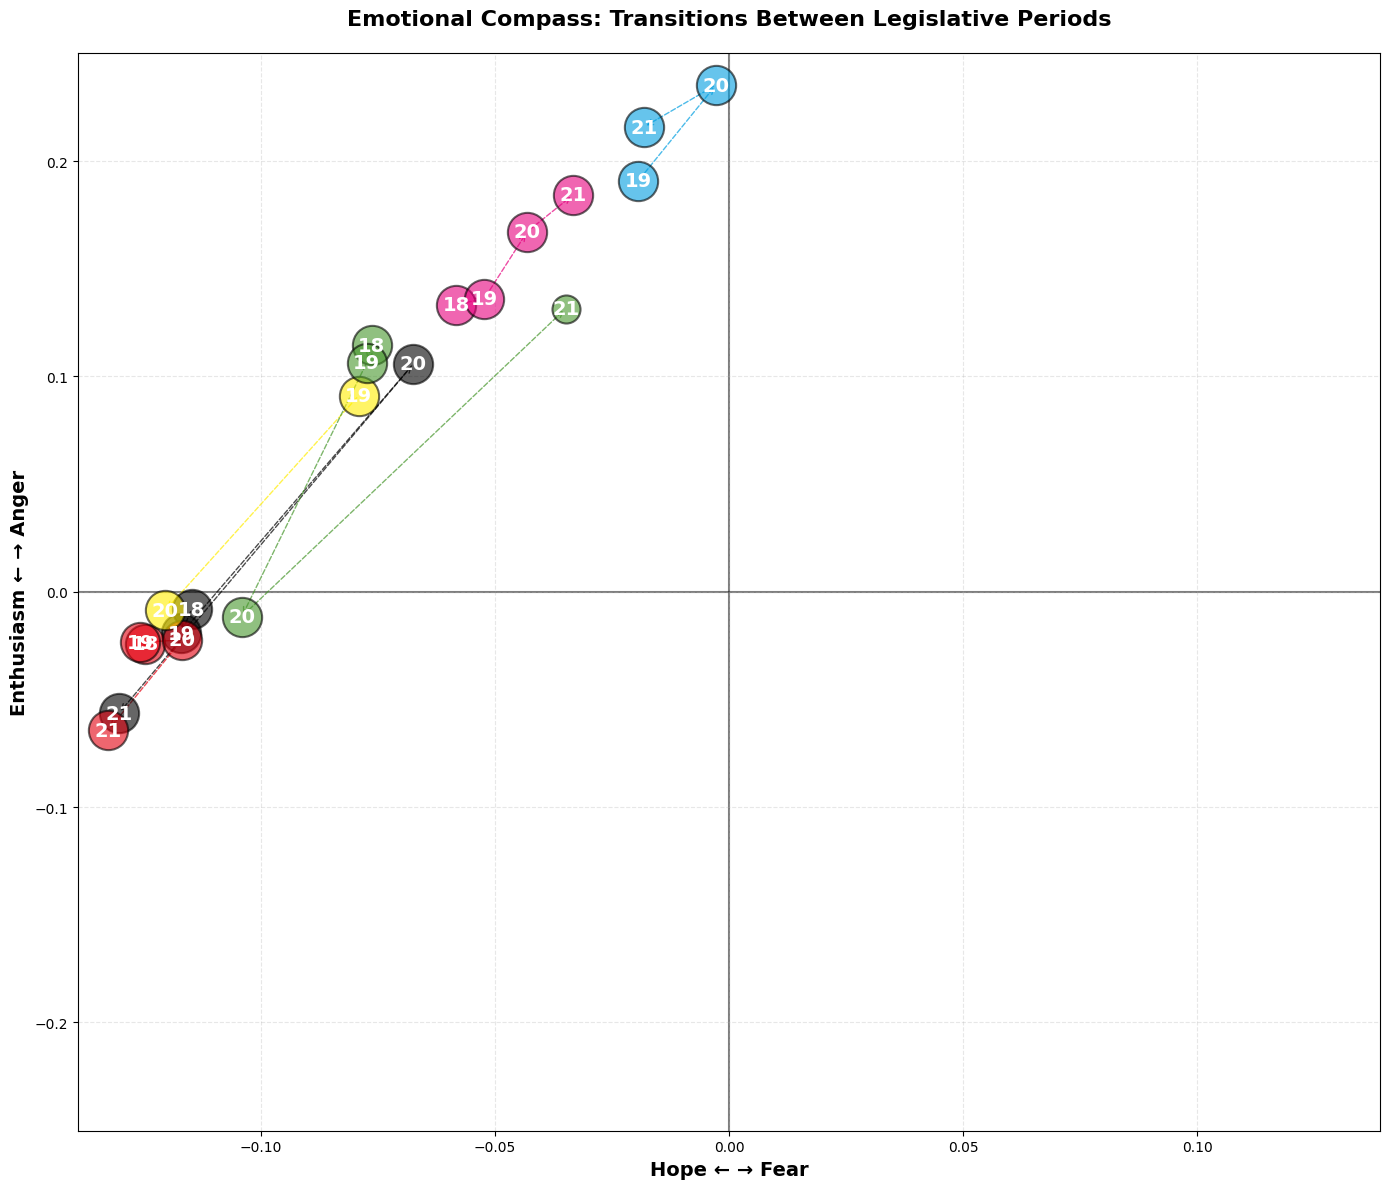

In [12]:
# Political Compass by Legislative Period
# Show how parties shift emotionally between legislative periods

def create_emotional_compass_by_legislature():    
    # Define legislative periods
    legislature_periods = [
        {'name': '18th (2013-2017)', 'start': '2013-10-22', 'end': '2017-10-22', 'label': '18'},
        {'name': '19th (2017-2021)', 'start': '2017-10-24', 'end': '2021-10-25', 'label': '19'},
        {'name': '20th (2021-2025)', 'start': '2021-10-26', 'end': '2025-03-24', 'label': '20'},
        {'name': '21st (2025-ongoing)', 'start': '2025-03-25', 'end': '2025-12-09', 'label': '21'}
    ]
    
    # FDP and AfD were NOT in Bundestag during 18th legislature (2013-2017)
    # They both entered in 19th legislature (2017-2021)
    parties_by_period = {
        '18': ['CDU/CSU', 'SPD', 'DIE LINKE', 'BÜNDNIS 90/DIE GRÜNEN'],  # No FDP, no AfD
        '19': parties_to_keep,  # All parties including FDP and AfD
        '20': parties_to_keep,  # All parties
        '21': parties_to_keep   # All parties
    }
    
    # Prepare data
    speech_data_copy = speech_data.copy()
    speech_data_copy['date'] = pd.to_datetime(speech_data_copy['date'])
    
    # Calculate positions for each party in each period
    period_positions = []
    
    for period in legislature_periods:
        period_start = pd.to_datetime(period['start'])
        period_end = pd.to_datetime(period['end'])
        
        period_speeches = speech_data_copy[
            (speech_data_copy['date'] >= period_start) & 
            (speech_data_copy['date'] <= period_end)
        ]
        
        # Only include parties that were actually in parliament during this period
        valid_parties = parties_by_period.get(period['label'], parties_to_keep)
        
        for party in valid_parties:
            party_speeches = period_speeches[period_speeches['party'] == party]
            
            if len(party_speeches) == 0:
                continue
            
            # Calculate average emotions
            hope = party_speeches['emotions'].apply(lambda x: x.get('Hope', 0)).mean()
            fear = party_speeches['emotions'].apply(lambda x: x.get('Fear', 0)).mean()
            anger = party_speeches['emotions'].apply(lambda x: x.get('Anger', 0)).mean()
            enthusiasm = party_speeches['emotions'].apply(lambda x: x.get('Enthusiasm', 0)).mean()
            
            period_positions.append({
                'party': party,
                'period': period['label'],
                'period_name': period['name'],
                'x': fear - hope,
                'y': anger - enthusiasm,
                'n_speeches': len(party_speeches)
            })
    
    position_df = pd.DataFrame(period_positions)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Plot positions and transitions for each party
    for party in parties_to_keep:
        party_data = position_df[position_df['party'] == party].sort_values('period')
        
        if len(party_data) == 0:
            continue
        
        color = party_colors.get(party, 'gray')
        
        # Plot each period's position
        for idx, row in party_data.iterrows():
            # Size based on number of speeches (more speeches = larger circle)
            size = min(max(row['n_speeches'] * 2, 100), 800)
            
            ax.scatter(row['x'], row['y'], s=size, color=color, alpha=0.6,
                      edgecolors='black', linewidths=1.5, zorder=3)
            
            # Add period label near the point
            ax.text(row['x'], row['y'], row['period'], ha='center', va='center',
                   fontsize=14, fontweight='bold', color='white', zorder=4)
        
        # Draw arrows between consecutive periods
        for i in range(len(party_data) - 1):
            current = party_data.iloc[i]
            next_period = party_data.iloc[i + 1]
            
            dx = next_period['x'] - current['x']
            dy = next_period['y'] - current['y']
            
            # Draw arrow with annotate for better control
            ax.annotate('', xy=(next_period['x'], next_period['y']),
                       xytext=(current['x'], current['y']),
                       arrowprops=dict(arrowstyle='->', color=color, lw=1, 
                                     alpha=0.7, linestyle='--'),
                       zorder=2)
    
    # Add quadrant lines
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)
    
    # Make axis limits symmetric
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    max_x = max(abs(xlim[0]), abs(xlim[1]))
    max_y = max(abs(ylim[0]), abs(ylim[1]))
    ax.set_xlim(-max_x, max_x)
    ax.set_ylim(-max_y, max_y)
    
    # Update limits after setting symmetric axes
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    label_offset_x = (xlim[1] - xlim[0]) * 0.05
    label_offset_y = (ylim[1] - ylim[0]) * 0.05
    
    
    # Labels and title
    ax.set_xlabel('Hope ← → Fear', fontsize=14, fontweight='bold')
    ax.set_ylabel('Enthusiasm ← → Anger', fontsize=14, fontweight='bold')
    ax.set_title('Emotional Compass: Transitions Between Legislative Periods',
                fontsize=16, fontweight='bold', pad=20)
    
    ax.grid(True, alpha=0.3, linestyle='--', zorder=0)
    
    plt.tight_layout()
    plt.show()

# Generate the compass by legislative period
create_emotional_compass_by_legislature()

In [37]:
# Government vs Opposition Analysis
from scipy.stats import ttest_ind

government_coalitions = {
    '18th': {'start': '2013-10-22', 'end': '2017-10-24', 'coalition': ['CDU/CSU', 'SPD']},
    '19th': {'start': '2017-10-24', 'end': '2021-10-26', 'coalition': ['CDU/CSU', 'SPD']},
    '20th': {'start': '2021-10-26', 'end': '2025-02-23', 'coalition': ['SPD', 'BÜNDNIS 90/DIE GRÜNEN', 'FDP']},
    '21st': {'start': '2025-02-23', 'end': '2026-12-31', 'coalition': ['SPD', 'CDU/CSU']}
}

parties_in_parliament = {
    '18th': ['CDU/CSU', 'SPD', 'DIE LINKE', 'BÜNDNIS 90/DIE GRÜNEN'],
    '19th': parties_to_keep,
    '20th': parties_to_keep,
    '21st': parties_to_keep
}

def assign_government_status(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['government_status'] = 'Opposition'
    df['legislature'] = ''
    
    for leg, info in government_coalitions.items():
        start, end = pd.to_datetime(info['start']), pd.to_datetime(info['end'])
        valid_parties = parties_in_parliament[leg]
        
        in_period = (df['date'] >= start) & (df['date'] < end) & df['party'].isin(valid_parties)
        
        for party in info['coalition']:
            mask = in_period & (df['party'] == party)
            df.loc[mask, 'government_status'] = 'Government'
            df.loc[mask, 'legislature'] = leg
        
        df.loc[in_period & (df['government_status'] == 'Opposition'), 'legislature'] = leg
    
    return df

def get_emotion_scores(df, emotion):
    return [row['emotions'][emotion] for _, row in df.iterrows() if emotion in row['emotions']]

speech_data_gov = assign_government_status(speech_data)
print(pd.crosstab(speech_data_gov['legislature'], speech_data_gov['government_status']))

emotions = ['Anger', 'Fear', 'Hope', 'Enthusiasm']
results = []

gov_speeches = speech_data_gov[speech_data_gov['government_status'] == 'Government']
opp_speeches = speech_data_gov[speech_data_gov['government_status'] == 'Opposition']

print("\nGovernment vs Opposition:")
for emotion in emotions:
    gov_scores = get_emotion_scores(gov_speeches, emotion)
    opp_scores = get_emotion_scores(opp_speeches, emotion)
    
    gov_mean, opp_mean = np.mean(gov_scores), np.mean(opp_scores)
    diff = gov_mean - opp_mean
    cohen_d = diff / np.std(gov_scores + opp_scores)
    
    t_stat, p_val = ttest_ind(gov_scores, opp_scores)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    
    print(f"{emotion:12} | Gov: {gov_mean:.3f} | Opp: {opp_mean:.3f} | Diff: {diff:+.3f} {sig:3} | d={cohen_d:+.2f}")
    
    results.append({
        'emotion': emotion,
        'gov_mean': gov_mean,
        'opp_mean': opp_mean,
        'diff': diff,
        'p_value': p_val,
        'cohen_d': cohen_d,
        'sig': sig
    })

results_df = pd.DataFrame(results)

government_status  Government  Opposition
legislature                              
                            0           1
18th                     8943        4620
19th                    14129       12598
20th                    12689       11039
21st                     3157        2094

Government vs Opposition:
Anger        | Gov: 0.113 | Opp: 0.237 | Diff: -0.124 *** | d=-1.08
Fear         | Gov: 0.046 | Opp: 0.066 | Diff: -0.020 *** | d=-0.40
Hope         | Gov: 0.166 | Opp: 0.118 | Diff: +0.048 *** | d=+0.64
Enthusiasm   | Gov: 0.134 | Opp: 0.092 | Diff: +0.042 *** | d=+0.66
